# A Rota do Neuroamante

## Introdução

> "Ah… sim, isso soa ótimo. [Eva, desabilitar simulação de gosto, AGORA!!]"

            - Dr. Watts momentos antes de ser forçado a comer dois potes inteiros de picles pelo bem da ciência

![img](https://64.media.tumblr.com/325907a936f86823be8605a0ae766582/ec850cce4aa5cb45-6d/s1280x1920/645c3aeb72e63228b95a29f6b7de50da5b56708d.jpg)

### Até a lua... 

A Sigmund Corp é uma empresa tecnológica do universo do jogo de RPG-Maker "To the Moon", e traz consigo um objetivo inusitado: dar a oportunidade a pacientes terminais de viver a vida que sempre sonharam. Para isso, eles contam com um dispositivo que consegue acessar as memórias do indivíduo e, depois de reconstruir uma timeline coerente de eventos (que estão naturalmente degradados devido a idade), "resetar" sua memória para dar espaço a uma nova "vida artificial" que somente o paciente experienciará dentro de sua cabeça. Entretanto, tal processo demanda a intervenção de dois profissionais, os Drs Neil Watts e Eva Rosalind, para identificar os padrões que permitem criar as conexões entre as informações e garantir o sucesso do procedimento. [1]

Salvo do absurdo do mundo RPG, dentro da programação, podemos construir algo que funciona de forma relativamente parecida com as redes neurais artificiais. Esse tipo de modelo de Machine Learning é muito popular por conseguir identificar padrões complexos e que recentemente vem se demonstrando muito eficiente para realizar previsões a partir de dados. 

➥ **Nesse notebook nós vamos:**

- Identificar e otimizar os hiperparâmetros de uma rede neural para resolver um problema de classificação binária, com dados não sequenciais, testando ao menos 100 arquiteturas diferentes durante sua otimização
- Aplicar ferramentas como EarlyStopping e Dropout em nosso modelo
- Testar a acurácia utilizando diferentes otimizadores

### Redes Neurais Artificais - uma breve explicação

As redes neurais são assim chamadas por basearem-se, literalmente, em redes neurais da biologia. Elas são um robusto modelo matemático que podem ser utilizadas para resolver problemas de regressão e classificação por meio de múltiplas "sinapses artificiais", aplicando pesos e funções de ativação sobre os dados que logo em seguida seguirão para os próximos neurônios. Assim, obtemos um modelo capaz compreender padrões complexos e nos retornar previsões bem ponderadas. Por essa lógica, é um modelo ideal para lidar com grandes fluxos de dados, uma vez que quanto maior for a quantidade de dados alimentados a ele, melhor será seu desempenho. [2]

### Multilayer Perceptron (MLP)

A MLP é um tipo de rede neural *feedforward* (passar adiante) composta por múltiplas camadas de neurônios conectadas. Ela ganha destaque por conseguir distinguir dados que não são linearmente separáveis. [3] No exemplo abaixo, podemos ver uma MLP de três camadas. A primeira camada é a camada de *input* - que por si só não carregar viés, uma vez que se trata apenas dos dados brutos que estamos alimentando para a máquina. As camadas intermediárias são chamadas *hidden layers* e é por onde os dados são processados por funções de ativação não lineares antes de alcançarem a camada de *output*, que é a previsão que queremos. O processo pelo qual MLP passam para aprender é chamado **backpropagation**. Nesse processo, os pesos e vieses são calculados por meio de regra da cadeia para minimizar a **função de perda**, que mede o erro do modelo.

![img](https://viso.ai/wp-content/uploads/2021/04/multilayer-perceptrons-MLP-concept-1.jpg)

Podemos entender melhor como esse modelo funciona aplicando na prática.

## Desenvolvimento

#### Importando as bibliotecas

A principal biblioteca que utilizaremos será a **PyTorch**. A PyTorch é destinada para instanciação de modelos de MLP de maneira prática e eficiente. Sua documentação está disponível na referência [4], e veremos como ela pode ser usada ao longo desse notebook. Além disso, você pode ter percebido que também importamos um framework chamado **Lightning** [5]. Descobriremos para que serve em breve.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import lightning as L
import pandas as pd
import numpy as np
from lightning.pytorch.callbacks import EarlyStopping
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from lightning.pytorch.callbacks import Callback
from torchmetrics.classification import BinaryAccuracy  
import matplotlib.pyplot as plt

#### Importando o dataset

Os dados que utilizaremos para esse notebook são provenientes do dataset **UCI Heart-Disease** [6], um clássico dataset científico de problema de multiclasse. Para fins de praticidade, vamos modelar uma rede neural para um problema de classificação binária, onde:

- 1 = O paciente possui doença cardíaca
- 0 = O paciente não possui doença cardíaca

O trecho para importação do dataset foi fornecido pelo próprio repositório, como listado abaixo. Ele é estruturado de modo a funcionar em qualquer máquina, desde que ela esteja conectada a internet.

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 

### Tratando os dados e dividindo em treino + validação e teste

Primeiro, precisamos tratar os dados do dataset para preencher valores ausentes (N/A) bem como aplicar normalizações. Mais importante ainda, devemos adaptar nosso target para lidar com binaridade (apenas 0 e 1). 

Você pode ter notado que, além da divisão entre treino e teste convencional, temos agora a validação. Essa pequena porcentagem de dados (normalmente correspondente a ~10% deles) nos ajuda a avaliarmos o desempenho da nossa rede neural. É por meio dela que podemos inferir se nosso modelo está aprendendo de verdade com os dados ou apenas decorando-os, por exemplo. Durante o split de dados, reservamos 10% deles para teste, enquanto os outros ~10% ficarão reservados para validação.

Antes de aplicarmos nosso normalizador, transformamos nossos dados X e y correspondentes a treino, validação e teste em datasets separados. Essa é uma boa forma de evitar vazamento de dados, uma vez que garantimos que o modelo não verá dados que não era para ele ver.

In [3]:
# Binarização e tratamento dos dados

X_tratado = X.fillna(X.median())
y_tratado = (y > 0).astype(int)

# Divisão treino+validação e teste

indices = X_tratado.index

indices_treino_val, indices_teste = train_test_split(
    indices, test_size=0.1, random_state=42,
)


indices_treino, indices_val = train_test_split(
    indices_treino_val, test_size=0.1, random_state=42,
)

# Transformar em datasets

X_train_pd = X_tratado.loc[indices_treino]
y_train_pd = y_tratado.loc[indices_treino]

X_val_pd = X_tratado.loc[indices_val]
y_val_pd = y_tratado.loc[indices_val]

X_test_pd = X_tratado.loc[indices_teste]
y_test_pd = y_tratado.loc[indices_teste]

# Normalizador 

scaler = StandardScaler()

X_treino_norm = scaler.fit_transform(X_train_pd)
X_val_norm = scaler.transform(X_val_pd)
X_teste_norm = scaler.transform(X_test_pd)

### Criando tensores

Para que nossos dados possam ser usados pelo Pytorch e pelo Lightning, precisamos convertê-los para tensores. Tensores são estruturas multidimensionais que podem ser indexadas em mais de duas dimensões. Eles são semelhantes a arrays de numpy, mas com a vantagem de que podem ser usados em GPU's [7].

In [4]:
# Transformando em tensor

X_treino_t = torch.tensor(X_treino_norm, dtype=torch.float32)
y_train_t = torch.tensor(y_train_pd.values, dtype=torch.float32).view(-1, 1)

X_teste_t = torch.tensor(X_teste_norm, dtype=torch.float32)
y_test_t = torch.tensor(y_test_pd.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_t = torch.tensor(y_val_pd.values, dtype=torch.float32).view(-1, 1)

Para fins de visualização, assim que ficam nossos dados em arrays e em tensores, respectivamente:

In [5]:
X_train_np = X_train_pd.to_numpy()
X_train_np

array([[57.,  1.,  4., ...,  1.,  0.,  7.],
       [43.,  1.,  4., ...,  1.,  0.,  7.],
       [41.,  1.,  2., ...,  2.,  0.,  6.],
       ...,
       [35.,  0.,  4., ...,  1.,  0.,  3.],
       [61.,  1.,  4., ...,  1.,  1.,  7.],
       [62.,  0.,  4., ...,  2.,  0.,  3.]], shape=(244, 13))

In [6]:
X_treino_t

tensor([[ 0.2225,  0.7312,  0.8883,  ..., -0.9587, -0.7093,  1.2178],
        [-1.3384,  0.7312,  0.8883,  ..., -0.9587, -0.7093,  1.2178],
        [-1.5614,  0.7312, -1.1958,  ...,  0.6771, -0.7093,  0.6992],
        ...,
        [-2.2303, -1.3677,  0.8883,  ..., -0.9587, -0.7093, -0.8565],
        [ 0.6685,  0.7312,  0.8883,  ..., -0.9587,  0.4001,  1.2178],
        [ 0.7800, -1.3677,  0.8883,  ...,  0.6771, -0.7093, -0.8565]])

### Criando uma rede neural MLP

Para criar qualquer rede neural, criamos uma classe que herda de `nn.Module`. A função `__init__` é uma função inicializadora obrigatória que permite que o Pytorch registre os parâmetros utilizáveis. 

Para otimização, temos uma série de hiperparâmetros com os quais podemos brincar. Alguns dos mais básicos seriam o **número de camadas neurais** e o **número de neurônios em cada uma dessas camadas**. Para isso, criamos uma lista vazia que permite montarmos as camadas de maneira dinamica, para no final juntarmos todas com `nn.Sequential`. Além desses, você sempre vai encontrar uma **função de ativação**, que nesse caso, é a `ReLU`. A ReLU é uma função definida por $A(x) = max(0, x)$. Isso basicamente significa que, se o input for positivo, ela retorna x - caso contrário, retorna 0 [8]. Dito isso, ela é ideal para problemas de classificação binária, o que justifica sua escolha. 

Um bom adicional para sua rede neural é a função de `Dropout`. O que ela faz é "desligar" aleatoriamente alguns neurônios durante o treinamento para ter certeza de que o modelo esteja aprendendo bem. Isso ajuda muito a prevenir overfitting. 

In [7]:
class minha_mlp(nn.Module):
    def __init__(self, num_dados_entrada, lista_neuronios, num_dados_saida, dropout):
        super().__init__() ## Função inicializadora

        camadas = [] 
        in_dim = num_dados_entrada #Guarda o tamanho da camada, começando com o numero bruto de dados de entrada. Ex: 5 dados

        for num_neuronios in lista_neuronios: ## Iteração sobre o número de camadas. Para cada camada , cria-se uma linear que conecta o 
                                                ## número de dados brutos ao número de neurônios presentes nela. 
            
            camadas.append(nn.Linear(in_dim, num_neuronios)) 
            camadas.append(nn.ReLU())
            camadas.append(nn.Dropout(dropout))
            in_dim = num_neuronios

        camadas.append(nn.Linear(in_dim, num_dados_saida))

        self.camadas = nn.Sequential(*camadas)
         
    def forward(self, x):
         
        return self.camadas(x)

Este é um bom ponto de partida para nossa MLP. Porém, podemos explorar ainda mais algumas ferramentas que potencialmente poderiam melhorar o desempenho de nossa rede neural. Enquanto é possível explorarmos isso em Pytorch puro, o **Lightning** disponibiliza estruturas pré-prontas que tornam essa exploração ainda mais dinâmica. 

### Pytorch, use Lightning!

Já que já temos nosso modelo pré-pronto, basta adaptarmos isso para o Lightning. Para isso, precisamos criar algo conhecido como `DataLoaders`. O Lightning funciona treinando em batches (porções) do dataset. Invés de usar todos os dados, ele pega algumas amostras de X e y e entrega-os no loop de treino. O número de amostras (batch_size) também pode ser otimizado! Além disso, temos também `num_workers` que define quantos núcleos de processamento (CPU) queremos usar no treinamento dos dados.

Abaixo, criamos um loader para treino e outro para validação.

In [8]:
def Loaders(X_train, y_train, X_val, y_val, batch_size, num_workers=0):
    
    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers)
    
    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=batch_size*2, 
        shuffle=False, 
        num_workers=num_workers)
    
    return train_loader, val_loader

Agora podemos criar nossa classe Lightning tranquilamente! A chamei de LitWrap pois ela vai basicamente "envolver" o modelo que criamos anteriormente (tal qual um wrap).

Aqui, podemos nos deparar com alguns nomes novos. Vamos passar por cada um deles.

O **Learning Rate** (taxa de aprendizado) simboliza o número de passos dados durante a otimização para minimizar a **função de perda**. Uma função de perda é utilizada para medir a diferença entre as previsões do modelo e os valores reais. Um valor de perda grande significa pouca acurácia do modelo - do contrário, o modelo consegue fazer boas previsões e está aprendendo bem com os dados. Nesse caso, optei por utilizar a função de perda `BCEWithLogitsLoss`. Ela é uma combinação entre uma função `Sigmoid` e a função de perda `BCE`, que é particularmente boa com classificação binária. Ela aplica, primeiro, a função Sigmoid para então calcular a perda com `BCE` [9]. 

A otimização por si só também pode ser... otimizada. Geralmente, podemos ver como modelos se comportam utilizando diferentes otimizadores para diferentes camadas, ou simplesmente testar o desempenho de diferentes otimizadores juntamente com um conjunto de hiperparâmetros, que é o que faremos. Na função `configure_optimizers`, deixamos em aberto para o optuna escolher qual otimizador usar. Limitei-me aos otimizadores `Adam`, `AdamW` e `SGD`. 

Além disso, temos também o parâmetro `weight_decay`. Ele é um regulador que ajuda a penalizar pesos muito grandes e garante que o modelo não "decore" dados. 

`BinaryAccuracy` é uma métrica de acurácia para classificação binária que será utilizada para nosso modelo.



In [9]:
class LitWrap(L.LightningModule):
    def __init__(
        self, modelo, lr, optmizer_name, weight_decay
    ):
        super().__init__()

        self.modelo = modelo
        self.lr = lr
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.optmizer_name = optmizer_name
        self.weight_decay = weight_decay
        self.val_acc = BinaryAccuracy()


    def forward(self, x):
        return self.modelo(x)

    ### Escolhendo o otimizador

    def configure_optimizers(self):
        
        params = self.modelo.parameters()

        name = self.optmizer_name.lower()
        if name == "adam":
            opt = optim.Adam(params, lr=self.lr, weight_decay=self.weight_decay)
        elif name == "adamw":
            opt = optim.AdamW(params, lr=self.lr, weight_decay=self.weight_decay)
        elif name == "sgd":
            opt = optim.SGD(params, lr=self.lr, momentum=0.9, weight_decay=self.weight_decay)

        return opt

     
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        
        self.log("train_loss", loss, on_epoch=True, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        
        
        preds = (logits >= 0).int()          
        acc = self.val_acc(preds, y.int())

        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)
        return loss

As funções `training_step` e `validation_step` definem o que vai acontecer no treino e validação, utilizando os conjuntos de amostras (batches) que fornecemos a elas. A função de perda é calculada para cada uma delas. Podemos armazenar os valores referentes a perda por meio de uma função `Callback`. Isso é usualmente preferível pois confere uma estrutura organizada e limpa. 

In [10]:
class Historico(Callback):
    
    def __init__(self):
    
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        tl = trainer.callback_metrics.get("train_loss")
        if tl is not None:
            self.train_losses.append(float(tl.detach().cpu()))

    def on_validation_epoch_end(self, trainer, pl_module):
        vl = trainer.callback_metrics.get("val_loss")
        if vl is not None:
            self.val_losses.append(float(vl.detach().cpu()))

Agora, passamos a variável local como global. Assim, é mais fácil recuperarmos nossos dados mais tarde.

In [11]:
hist_loss = Historico()

## Otimização com o Optuna

O Optuna é um framework de otimização de hiperparâmetros que consegue automaticamente criar um espaço de estudo que testa múltiplas arquiteturas de hiperparâmetros para o modelo [10]. Abaixo, além dos parâmetros que mencionamos previamente, também incluímos otimização para `batch_size` (tamanho dos lotes) e `weight_decay`, uma técnica de regularização que ajuda a evitar sobreajuste. 

Adicionamos também a função `EarlyStopping` disponibilizada pelo Lightning. Essa função consegue otimizar o número de épocas ideal para o modelo de acordo com o desempenho dele. Para essa, também temos dois parâmetros otimizáveis: `patience`, que define quão tolerante a função é em relação a um dado número de épocas onde o modelo não apresenta melhora, e `min_delta`, que define a mudança mínima na quantidade monitorada que se qualifica como melhoria [11]. Por fim, chamamos também os otimizadores que queremos testar.

A função `Trainer` do Lightning pega tudo que definimos em `LitWrap` e executa juntamente com os hiperparâmetros fornecidos pelo Optuna em cada trial. Podemos então registrar a acurácia do modelo criado com essas condições em um `callback`. 

In [12]:
def objective(trial):

    n_camadas = trial.suggest_int("n_camadas", 1, 5)

    n_epocas = trial.suggest_int("n_epocas", 30, 100)

    lista_neuronios = []
    for i in range(n_camadas): 
        n_neuronios = trial.suggest_int(f"n_l{i}", 4, 32)
        lista_neuronios.append(n_neuronios)

    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    dropout = trial.suggest_float("dropout", 0.1, 0.3)

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    optmizer_name = trial.suggest_categorical("optmizer", ["Adam", "AdamW", "SGD"])

    base = minha_mlp(X_treino_t.shape[1], lista_neuronios, 1, dropout=dropout)
    lit_model = LitWrap(base, lr=lr, optmizer_name=optmizer_name, weight_decay=weight_decay)

    train_loader, val_loader = Loaders(X_treino_t, y_train_t, X_val_t, y_val_t, batch_size=batch_size)
    
    early_stop = EarlyStopping(
        monitor="val_acc",     
        mode="max",             
        patience=trial.suggest_int("patience", 1, 10),
        min_delta=trial.suggest_float("min_delta", 1e-5, 1e-2, log=True),
        verbose=False
    )

    trainer = L.Trainer(
        max_epochs=n_epocas,
        callbacks=[early_stop],
        enable_checkpointing=False,  
        logger=False,
        log_every_n_steps=1,
        enable_progress_bar=False,
        deterministic=True
    )

    trainer.fit(lit_model, train_loader, val_loader)
    
    
   
    val_acc = trainer.callback_metrics.get("val_acc")
    if val_acc is None:
        return 0.0
    return float(val_acc.cpu().item())

### Estudo

In [13]:
study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials=100, timeout=600)

[I 2026-04-06 22:10:00,172] A new study created in memory with name: no-name-2fb4cb6a-bfad-4e43-aa20-c638f8ffeb7b
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | modelo  | minha_mlp         | 277    | train
1 | loss_fn | BCEWithLogitsLoss | 0      | train
2 | val_acc | BinaryAccuracy    | 0      | train
------------------------------------------------------
277       Trainable params
0         Non-trainable params
277       Total params
0.001     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
C:\venvs\ilumpy\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to im

## Resultados

Podemos checar qual foi a melhor arquitetura projetada pelo optuna dentro dessas 100 trials:

In [14]:
print(f"Melhor Acurácia: {study.best_value:.4f}")
print("Melhores Hiperparâmetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Melhor Acurácia: 0.8929
Melhores Hiperparâmetros:
  n_camadas: 1
  n_epocas: 57
  n_l0: 4
  lr: 0.002794794295357504
  dropout: 0.26009665153468847
  batch_size: 16
  weight_decay: 1.6910512219994432e-06
  optmizer: Adam
  patience: 7
  min_delta: 0.0015046006107584562


Além disso, podemos conferir como foi o desempenho de cada otimizador analisando o seu valor "best" (valor de máximo desempenho dado um número de vezes em que ele foi escolhido pelo optuna).

In [15]:
for opt in ["Adam", "AdamW", "SGD"]:
    vals = [
        t.value for t in study.trials
        if t.value is not None and t.params.get("optmizer") == opt]

    print(f"{opt:6s} | BEST = {np.max(vals):.4f}  (n={len(vals)})")

Adam   | BEST = 0.8929  (n=78)
AdamW  | BEST = 0.8929  (n=11)
SGD    | BEST = 0.8571  (n=11)


Agora que sabemos quais são os melhores parametros para o nosso modelo, podemos informar isso para o nosso modelo:

In [16]:
parametros = study.best_params

melhor_lista = [parametros[f"n_l{i}"] for i in range(parametros["n_camadas"])]

modelo_base_final = minha_mlp(X_treino_norm.shape[1], melhor_lista, 1, dropout=parametros["dropout"])

modelo_lit_final = LitWrap(modelo_base_final, lr=parametros["lr"], optmizer_name=parametros["optmizer"], weight_decay=parametros["weight_decay"])

Em seguida, criamos os DataLoaders finais (com batches otimizados):

In [17]:
## Loaders finais

train_loader, val_loader = Loaders(
    X_treino_t, y_train_t,
    X_val_t, y_val_t,
    batch_size=parametros["batch_size"]
)


E o EarlyStop, com seus parâmetros otimizados:

In [18]:
## Early Stopping final

early_stop_final = EarlyStopping(
    monitor="val_loss",       
    mode="min",               
    patience=parametros["patience"],
    min_delta=parametros["min_delta"]
)

Finalmente, podemos treinar nosso modelo definitivo com a função `Trainer`, seguida de um `fit`.

In [20]:
trainer_final = L.Trainer(
    num_sanity_val_steps=0,
    max_epochs=parametros["n_epocas"],
    callbacks=[early_stop_final, hist_loss],
    enable_checkpointing=False,
    logger=False
)

trainer_final.fit(
    modelo_lit_final,
    train_loader,
    val_loader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | modelo  | minha_mlp         | 61     | train
1 | loss_fn | BCEWithLogitsLoss | 0      | train
2 | val_acc | BinaryAccuracy    | 0      | train
------------------------------------------------------
61        Trainable params
0         Non-trainable params
61        Total params
0.000     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

## Previsões

Se quisermos ser chiques, podemos visualizar previsões realizadas pelo nosso modelo (em forma de tensores e de classes).

In [21]:
X_todo_norm = scaler.transform(X_tratado)
X_todo_norm = torch.tensor(X_todo_norm, dtype=torch.float32)

modelo_lit_final(X_todo_norm)[:10]

tensor([[ 0.4929],
        [ 3.6430],
        [ 0.2296],
        [-1.4799],
        [-4.4166],
        [-3.2897],
        [ 2.4026],
        [-0.9439],
        [ 2.2444],
        [ 2.1863]], grad_fn=<SliceBackward0>)

In [22]:
predictions = torch.where(modelo_lit_final(X_todo_norm) > .5, 1, 0)[:15]
predictions

tensor([[0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [0],
        [1],
        [0],
        [0]])

Com a nossa função `CallBack`, podemos também plotar um gráfico para visualizar o desempenho da nossa rede neural. Essa é uma das formas mais explicitas de se identificar problemas de sobreajuste. A linha laranja representa a curva referente ás perdas da validação, enquanto a curva azul representa a curva referente as perdas de treino. Quanto mais próximo essas linhas estiverem uma das outras, melhor o desempenho. 

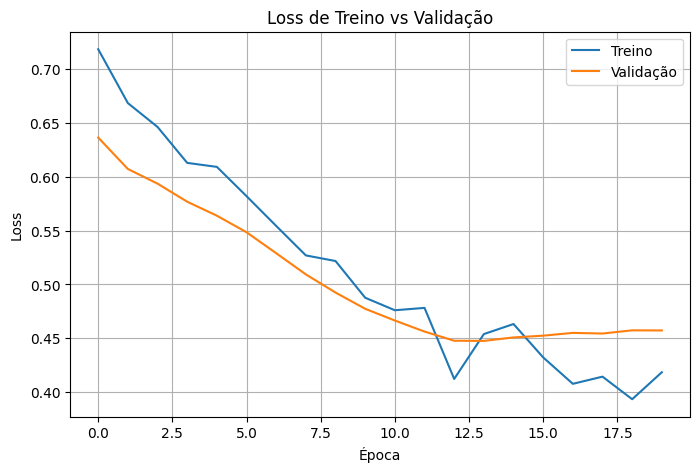

In [23]:
plt.figure(figsize=(8,5))
plt.plot(hist_loss.train_losses, label="Treino")
plt.plot(hist_loss.val_losses, label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss de Treino vs Validação")
plt.legend()
plt.grid(True)
plt.show()

## Considerações finais

Para muitos datasets pequenos como o Heart-Disease, mais pode ser menos. Apesar disso, conseguimos obter um resultado razoável e esperado para um conjunto de dados como ele [6]. Em modelos mais simples e menos robustos, o modelo parece convergir melhor. De todo modo, foi possível explorar e testar diferentes arquiteturas de hiperparâmetros e otimizadores interessantes para o nosso modelo, deixando ressaltado a importância dessa prática para o aprendizado de máquina.

## Referências

[1] Wikifandom de "To the Moon". Disponível em: https://tothemoon.fandom.com/wiki/To_the_Moon

[2] "O que é uma rede neural?", IBM. Disponível em: https://www.ibm.com/br-pt/think/topics/neural-networks

[3] "Multilayer Perceptron". Disponível em: https://en.wikipedia.org/wiki/Multilayer_perceptron

[4] Documentação Oficial do Pytorch: https://docs.pytorch.org/docs/stable/index.html

[5] Site do Lightning: https://lightning.ai/docs/pytorch/stable/

[6] Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.

[7] "Explorando tensores com Pytorch", A. Matheus. Disponível em: https://imsouza.github.io/posts/explorando-tensores-com-pytorch

[8] "Activation functions in Neural Networks", GeeksForGeeks. Disponível em: https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/

[9] "Understanding `BCEWithLogitsLoss` in PyTorch". Disponível em: https://www.codegenes.net/blog/examplebcewithlogitsloss-pytorch/

[10] Optuna: https://optuna.org/

[11] Documentação Lightning: https://lightning.ai/docs/pytorch/stable/common/early_stopping.html

#### Referências complementares

"Intro to Binary Classification with PyTorch" por Jacob Khoeler. Disponível em: https://www.youtube.com/watch?v=z1oDlzngvI0

"Introduction to Coding Neural Networks with PyTorch and Lightning" por StatsQuest. Disponível em: https://www.youtube.com/watch?v=khMzi6xPbuM&t=410s

Playlist didática sobre uso do Lightning para Pytorch, por Lightning AI. Disponível em: https://www.youtube.com/playlist?list=PLaMu-SDt_RB5hhJKZC5a6HPdlDTawUT3r

#### Uso de IA

A IA "Copilot" foi utilizada nesse notebook por meio de um agente personalizado para aprimorar trechos e identificar eventuais erros de lógica observados no código ao longo de seu desenvolvimento, bem como obter um esclarecimento mais aprofundado sobre o seu funcionamento e sugerir correções.

![img](https://illustplus.net/uploads/illust/color_img/7305/l_hosi1_c.png)